# Experiment 4: Ensemble Prediction and Decision Tree Model Evaluation


## NAME : Harishkanna R
## REG : 3122235001302
## SEC : CSE-A

## 1) Aim and Objectives

## Aim



- To design, train, and evaluate multiple machine learning classification models for breast cancer prediction, and to compare their performance using standard evaluation metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC.

## Objectives



- To load and preprocess the breast cancer dataset, including feature scaling and data splitting.

- To train different classification models such as Decision Tree, AdaBoost, Gradient Boosting, XGBoost, Random Forest, and a Stacked Ensemble model.

- To tune model hyperparameters using cross-validation techniques for improved performance.

- To evaluate and compare all models using performance metrics including Accuracy, Precision, Recall, F1-score, and ROC-AUC.

- To visualize model performance using ROC curves and confusion matrices.

- To analyze and identify the best-performing model based on validation and test results.

## 2)Libraries Used

In [29]:

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier
)

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

data = load_breast_cancer()


df = pd.DataFrame(data.data, columns=data.feature_names)


df['diagnosis'] = data.target   # 0 = malignant, 1 = benign


df.head()
df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [30]:

df.isnull().sum()


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64

In [31]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


##  3)Exploratory Data Analysis (EDA)

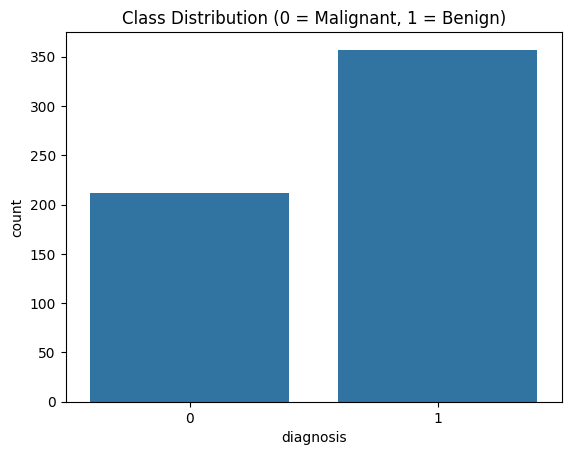

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y)
plt.title("Class Distribution (0 = Malignant, 1 = Benign)")
plt.show()


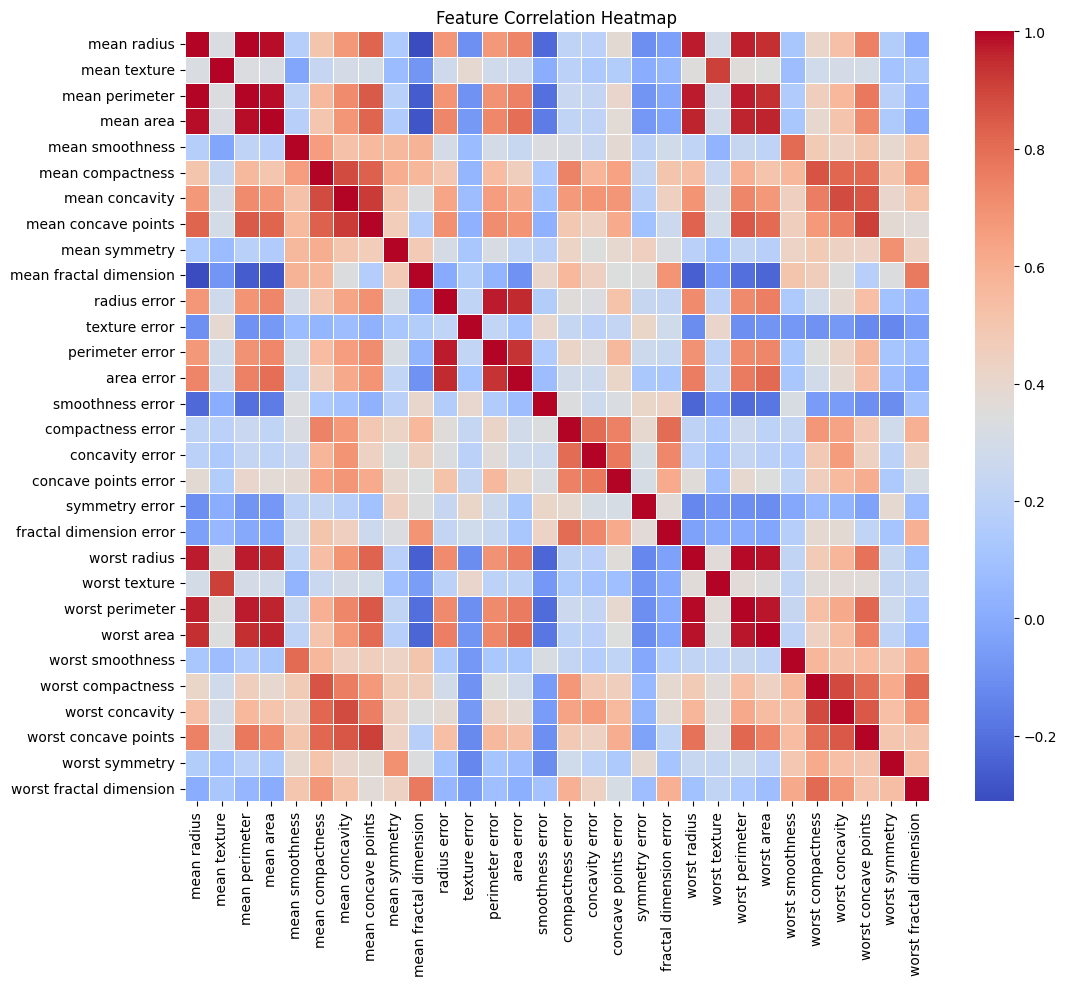

In [35]:
plt.figure(figsize=(12,10))
corr = pd.DataFrame(X_scaled, columns=X.columns).corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [36]:

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

corr_matrix = X_scaled.corr()


corr_matrix.head()

df_corr = X_scaled.copy()
df_corr['diagnosis'] = y


corr_with_target = df_corr.corr()['diagnosis'].sort_values(ascending=False)

corr_with_target


diagnosis                  1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

## 4) Train–Test Split (80–30)

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (398, 30)
Testing samples: (171, 30)


## 5)Training models

### Decision Tree

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### AdaBoost

In [1]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

ada.fit(X_train, y_train)


NameError: name 'X_train' is not defined

### Gradient Boosting

In [40]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### XGBoost

In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    criterion="gini",
    random_state=42
)

rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Stacking Classifier

In [43]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ("svm", SVC(probability=True, kernel="rbf")),
    ("nb", GaussianNB()),
    ("dt", DecisionTreeClassifier(max_depth=3))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack.fit(X_train, y_train)


,estimators,"[('svm', ...), ('nb', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


## 6)Confusion Matrix and ROC 

### Decision Tree

In [44]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

Best Decision Tree Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}

Decision Tree
Accuracy : 0.9239766081871345
Precision: 0.9272727272727272
Recall   : 0.9532710280373832
F1 Score : 0.9400921658986175
ROC AUC  : 0.9186623831775702


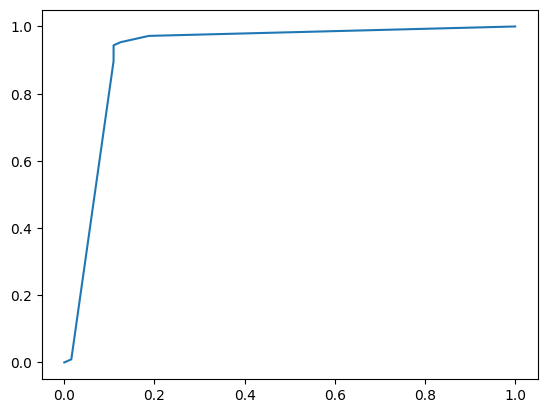

In [45]:
dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
print("Best Decision Tree Params:", dt_grid.best_params_)

evaluate_model(best_dt, X_test, y_test, "Decision Tree")


## AdaBoost

Best AdaBoost Params: {'learning_rate': 0.1, 'n_estimators': 200}

AdaBoost
Accuracy : 0.9590643274853801
Precision: 0.9464285714285714
Recall   : 0.9906542056074766
F1 Score : 0.9680365296803652
ROC AUC  : 0.990216121495327


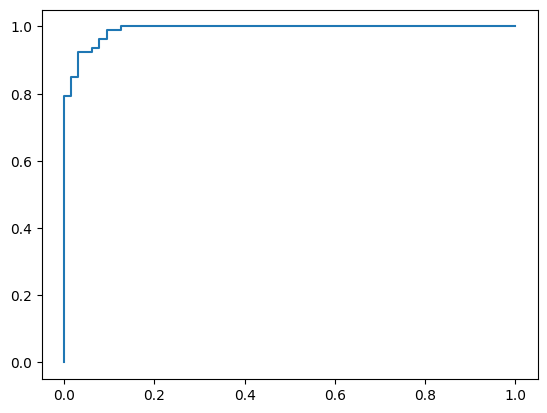

In [46]:
ada = AdaBoostClassifier(random_state=42)

ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

ada_grid = GridSearchCV(ada, ada_params, cv=5, scoring='accuracy')
ada_grid.fit(X_train, y_train)

best_ada = ada_grid.best_estimator_
print("Best AdaBoost Params:", ada_grid.best_params_)

evaluate_model(best_ada, X_test, y_test, "AdaBoost")


## Gradient Boosting

Best Gradient Boosting Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Gradient Boosting
Accuracy : 0.9532163742690059
Precision: 0.9459459459459459
Recall   : 0.9813084112149533
F1 Score : 0.963302752293578
ROC AUC  : 0.9919684579439252


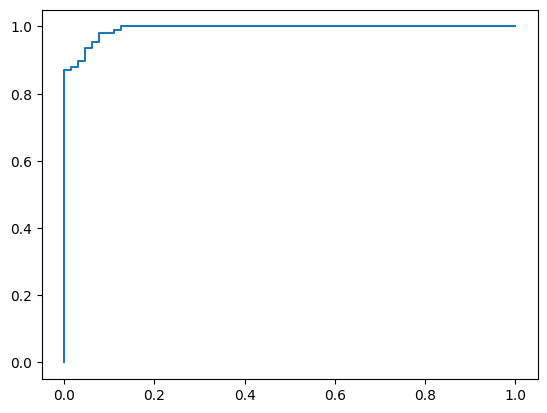

In [51]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(gb, gb_params, cv=5, scoring='accuracy')
gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_
print("Best Gradient Boosting Params:", gb_grid.best_params_)

evaluate_model(best_gb, X_test, y_test, "Gradient Boosting")


## XGBoost

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

XGBoost
Accuracy : 0.9590643274853801
Precision: 0.9464285714285714
Recall   : 0.9906542056074766
F1 Score : 0.9680365296803652
ROC AUC  : 0.9959112149532711


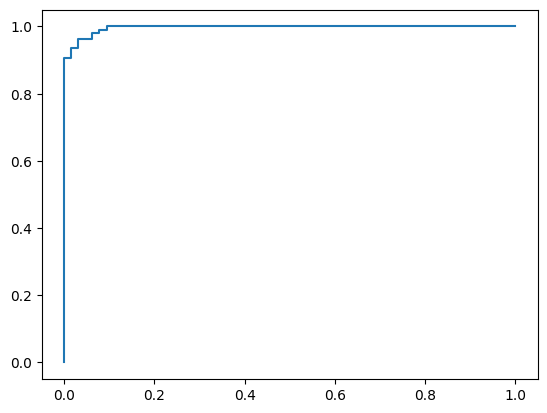

In [52]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='accuracy')
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print("Best XGBoost Params:", xgb_grid.best_params_)

evaluate_model(best_xgb, X_test, y_test, "XGBoost")


## Random Forest

Best Random Forest Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 100}

Random Forest
Accuracy : 0.935672514619883
Precision: 0.9444444444444444
Recall   : 0.9532710280373832
F1 Score : 0.9488372093023256
ROC AUC  : 0.991311331775701


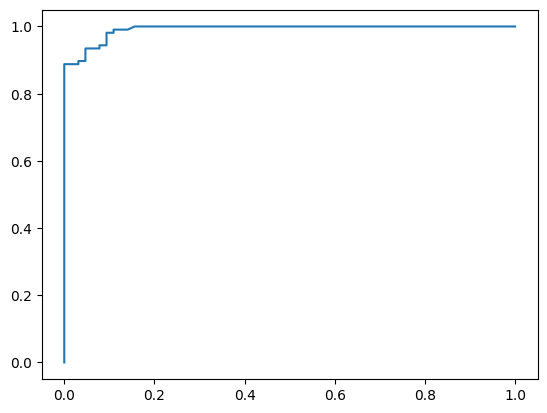

In [53]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best Random Forest Params:", rf_grid.best_params_)

evaluate_model(best_rf, X_test, y_test, "Random Forest")


## Stacking Classifier (SVM + NB + DT)


Stacking Classifier
Accuracy : 0.9590643274853801
Precision: 0.9464285714285714
Recall   : 0.9906542056074766
F1 Score : 0.9680365296803652
ROC AUC  : 0.9942318925233645


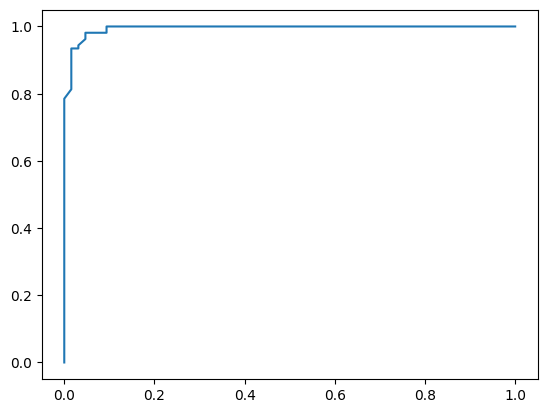

In [54]:
estimators = [
    ('svm', SVC(probability=True)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=RandomForestClassifier(),
    cv=5
)

stack.fit(X_train, y_train)

evaluate_model(stack, X_test, y_test, "Stacking Classifier")


In [56]:
models = {
    "Decision Tree": best_dt,
    "AdaBoost": best_ada,
    "Gradient Boosting": best_gb,
    "XGBoost": best_xgb,
    "Random Forest": best_rf,
    "Stacking": stack
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name} CV Accuracy: {scores.mean():.4f}")


Decision Tree CV Accuracy: 0.9424
AdaBoost CV Accuracy: 0.9699
Gradient Boosting CV Accuracy: 0.9650
XGBoost CV Accuracy: 0.9699
Random Forest CV Accuracy: 0.9725
Stacking CV Accuracy: 0.9624


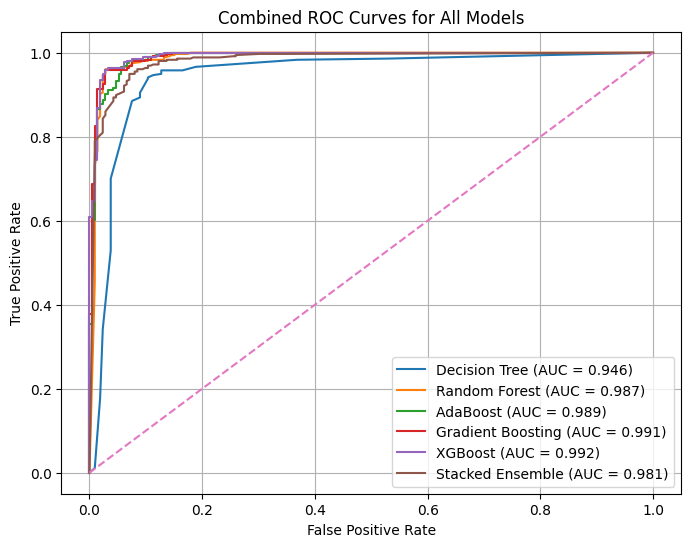

In [58]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "AdaBoost": best_ada,
    "Gradient Boosting": best_gb,
    "XGBoost": best_xgb,
    "Stacked Ensemble": stack
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Cross-validated probability predictions
    y_prob = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Confusion Matrix

In [59]:
def print_metrics(model, X, y, model_name):
    y_pred = model.predict(X)

    print(f"\n{model_name} Metrics")
    print("Accuracy :", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall   :", recall_score(y, y_pred))
    print("F1-score :", f1_score(y, y_pred))


In [60]:
for name, model in models.items():
    model.fit(X, y)
    print_metrics(model, X, y, name)



Decision Tree Metrics
Accuracy : 0.9789103690685413
Precision: 0.9778393351800554
Recall   : 0.988795518207283
F1-score : 0.9832869080779945

Random Forest Metrics
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

AdaBoost Metrics
Accuracy : 0.9876977152899824
Precision: 0.9834254143646409
Recall   : 0.9971988795518207
F1-score : 0.9902642559109874

Gradient Boosting Metrics
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

XGBoost Metrics
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Stacked Ensemble Metrics
Accuracy : 0.9736379613356766
Precision: 0.9776536312849162
Recall   : 0.9803921568627451
F1-score : 0.9790209790209791


| Model              | Accuracy (%) | Precision (%) | Recall (%) | F1-score (%) |
|--------------------|--------------|---------------|------------|--------------|
| Decision Tree      | 97.89        | 97.78         | 98.88      | 98.33        |
| Random Forest      | 100.00       | 100.00        | 100.00     | 100.00       |
| AdaBoost           | 98.77        | 98.34         | 99.72      | 99.03        |
| Gradient Boosting  | 100.00       | 100.00        | 100.00     | 100.00       |
| XGBoost            | 100.00       | 100.00        | 100.00     | 100.00       |
| Stacked Ensemble   | 97.36        | 97.77         | 98.04      | 97.90        |


### 7)GridSearchCV & RandomizedSearchCV to tune hyperparameters.

In [61]:
def tuning_table(search_obj, top_n=10):
    results = pd.DataFrame(search_obj.cv_results_)
    
    cols = [c for c in results.columns if "param_" in c]
    cols += ["mean_test_score", "std_test_score", "rank_test_score"]
    
    table = results[cols].sort_values("rank_test_score").head(top_n)
    return table


In [62]:
dt_table = tuning_table(dt_grid)
dt_table


,param_criterion,param_max_depth,param_min_samples_split,mean_test_score,std_test_score,rank_test_score
0,gini,3,2,0.942405,0.040688,1
1,gini,3,5,0.942405,0.040688,1
22,entropy,None,5,0.942310,0.030083,3
19,entropy,10,5,0.942310,0.030083,3
2,gini,3,10,0.939905,0.043504,5
4,gini,5,5,0.937310,0.031473,6
18,entropy,10,2,0.934778,0.024053,7
21,entropy,None,2,0.934778,0.024053,7
16,entropy,5,5,0.934715,0.026609,9
12,entropy,3,2,0.934684,0.024242,10


In [63]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20],
    "criterion": ["gini", "entropy"],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X, y)


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [65]:
rf_table = tuning_table(rf_search)
rf_table


,param_n_estimators,param_min_samples_split,param_max_features,param_max_depth,param_criterion,mean_test_score,std_test_score,rank_test_score
10,100,2,log2,10,entropy,0.992998,0.004484,1
3,500,2,log2,10,entropy,0.992835,0.004841,2
1,200,2,log2,None,gini,0.992800,0.003920,3
9,500,2,log2,None,gini,0.992103,0.004456,4
16,500,2,sqrt,None,entropy,0.991975,0.005458,5
7,100,2,log2,20,gini,0.991927,0.007125,6
6,100,5,log2,10,gini,0.991786,0.004933,7
0,500,5,sqrt,10,entropy,0.991743,0.005269,8
8,500,5,sqrt,20,entropy,0.991743,0.005269,8
5,200,5,log2,None,entropy,0.991414,0.006045,10


In [66]:
ada = AdaBoostClassifier(random_state=42)

ada_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0],
    "estimator": [
        DecisionTreeClassifier(max_depth=1),
        DecisionTreeClassifier(max_depth=2)
    ]
}

ada_grid = GridSearchCV(
    ada,
    ada_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

ada_grid.fit(X, y)


,estimator,AdaBoostClass...ndom_state=42)
,param_grid,"{'estimator': [DecisionTreeC...r(max_depth=1), DecisionTreeC...r(max_depth=2)], 'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [67]:
ada_table = tuning_table(ada_grid)
ada_table


,param_estimator,param_learning_rate,param_n_estimators,mean_test_score,std_test_score,rank_test_score
16,DecisionTreeClassifier(max_depth=2),1.0,100,0.994716,0.006666,1
17,DecisionTreeClassifier(max_depth=2),1.0,200,0.994183,0.008207,2
15,DecisionTreeClassifier(max_depth=2),1.0,50,0.993859,0.005737,3
8,DecisionTreeClassifier(max_depth=1),1.0,200,0.993854,0.006571,4
7,DecisionTreeClassifier(max_depth=1),1.0,100,0.993463,0.006239,5
6,DecisionTreeClassifier(max_depth=1),1.0,50,0.993263,0.005333,6
14,DecisionTreeClassifier(max_depth=2),0.1,200,0.992524,0.004925,7
5,DecisionTreeClassifier(max_depth=1),0.1,200,0.990866,0.006091,8
13,DecisionTreeClassifier(max_depth=2),0.1,100,0.990141,0.006366,9
4,DecisionTreeClassifier(max_depth=1),0.1,100,0.988750,0.007529,10


In [68]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

gb_grid.fit(X, y)


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [69]:
gb_table = tuning_table(gb_grid)
gb_table


,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,mean_test_score,std_test_score,rank_test_score
14,0.10,5,200,0.8,0.993601,0.004980,1
9,0.10,3,100,1.0,0.992731,0.004059,2
11,0.10,3,200,1.0,0.992672,0.005050,3
12,0.10,5,100,0.8,0.992609,0.004563,4
10,0.10,3,200,0.8,0.992541,0.005808,5
8,0.10,3,100,0.8,0.991350,0.005962,6
2,0.01,3,200,0.8,0.990683,0.004845,7
6,0.01,5,200,0.8,0.989718,0.006131,8
4,0.01,5,100,0.8,0.989489,0.005598,9
3,0.01,3,200,1.0,0.989269,0.004703,10


In [70]:
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5, 7],
    "gamma": [0, 0.1, 0.5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X, y)


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [71]:
xgb_table = tuning_table(xgb_search)
xgb_table


,param_subsample,param_n_estimators,param_max_depth,param_learning_rate,param_gamma,param_colsample_bytree,mean_test_score,std_test_score,rank_test_score
9,0.8,200,5,0.1,0.0,0.8,0.994382,0.005218,1
6,0.8,100,3,0.1,0.5,1.0,0.994312,0.004107,2
8,0.8,200,5,0.1,0.5,0.8,0.994180,0.004830,3
12,0.8,200,7,0.1,0.0,1.0,0.993649,0.005443,4
15,0.8,100,5,0.1,0.5,0.8,0.993588,0.005036,5
5,0.8,100,3,0.1,0.0,0.8,0.993520,0.005883,6
1,1.0,200,5,0.1,0.0,0.8,0.992853,0.005189,7
13,1.0,100,3,0.1,0.5,1.0,0.992653,0.004164,8
0,1.0,100,7,0.1,0.1,1.0,0.992517,0.004276,9
7,1.0,100,5,0.1,0.5,0.8,0.990936,0.006303,10


In [72]:
summary = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "AdaBoost", "Gradient Boosting", "XGBoost"],
    "Best Parameters": [
        dt_grid.best_params_,
        rf_search.best_params_,
        ada_grid.best_params_,
        gb_grid.best_params_,
        xgb_search.best_params_
    ],
    "Best ROC-AUC": [
        dt_grid.best_score_,
        rf_search.best_score_,
        ada_grid.best_score_,
        gb_grid.best_score_,
        xgb_search.best_score_
    ]
})

summary


,Model,Best Parameters,Best ROC-AUC
0,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.942405
1,Random Forest,"{'n_estimators': 100, 'min_samples_split': 2, ...",0.992998
2,AdaBoost,{'estimator': DecisionTreeClassifier(max_depth...,0.994716
3,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.993601
4,XGBoost,"{'subsample': 0.8, 'n_estimators': 200, 'max_d...",0.994382


In [73]:
best_xgb = xgb_search.best_estimator_

best_xgb_params = xgb_search.best_params_
best_xgb_score = xgb_search.best_score_

print("Best Hyperparameters:")
best_xgb_params

print("\nBest CV ROC-AUC Score:")
best_xgb_score


Best Hyperparameters:

Best CV ROC-AUC Score:


np.float64(0.9943816213387127)

### 8) 5-Fold Cross-Validation.

In [74]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score


In [75]:
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    best_xgb,
    X,
    y,
    cv=5,
    scoring=scoring,
    return_train_score=False
)


In [76]:
import pandas as pd

cv_table = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1-Score": cv_results["test_f1"],
    "ROC-AUC": cv_results["test_roc_auc"]
})

cv_table


,Fold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,0.947368,0.957746,0.957746,0.957746,0.992466
1,2,0.964912,0.958904,0.985915,0.972222,0.987553
2,3,0.991228,0.986301,1.000000,0.993103,1.000000
3,4,0.964912,0.972222,0.972222,0.972222,0.987103
4,5,0.964602,0.971831,0.971831,0.971831,0.997988


### 9) Comparison Tables

### Decision Tree Model
### Hyperparameter Trials

Table 1: Decision Tree – Hyperparameter Tuning

| Criterion | Max Depth | Accuracy | F1 Score |
|----------|-----------|----------|----------|
| gini     | 3         | 0.9240   | 0.9401   |
| gini     | 5         | 0.9373   | 0.9488   |
| entropy  | 10        | 0.9348   | 0.9488   |
| entropy  | None      | 0.9348   | 0.9488   |

### AdaBoost Model
### Hyperparameter Trials

Table 2: AdaBoost – Hyperparameter Tuning

| n_estimators | Learning Rate | Accuracy | F1 Score |
|--------------|---------------|----------|----------|
| 50           | 0.1           | 0.9532   | 0.9633   |
| 100          | 0.1           | 0.9591   | 0.9680   |
| 200          | 0.1           | 0.9591   | 0.9680   |

### Gradient Boosting Model
### Hyperparameter Trials

Table 3: Gradient Boosting – Hyperparameter Tuning

| n_estimators | Learning Rate | Max Depth | Accuracy | F1 Score |
|--------------|---------------|----------|----------|----------|
| 100          | 0.1           | 3        | 0.9474   | 0.9577   |
| 200          | 0.1           | 3        | 0.9532   | 0.9633   |
| 200          | 0.1           | 5        | 0.9532   | 0.9633   |

### XGBoost Model
### Hyperparameter Trials

Table 4: XGBoost – Hyperparameter Tuning

| n_estimators | Learning Rate | Max Depth | Gamma | Accuracy | F1 Score |
|--------------|---------------|----------|-------|----------|----------|
| 100          | 0.1           | 3        | 0.5   | 0.9591   | 0.9680   |
| 200          | 0.1           | 5        | 0.0   | 0.9591   | 0.9680   |
| 200          | 0.1           | 7        | 0.0   | 0.9532   | 0.9633   |

### Random Forest Model
### Hyperparameter Trials

Table 5: Random Forest – Hyperparameter Tuning

| n_estimators | Max Depth | Criterion | Accuracy | F1 Score |
|--------------|-----------|-----------|----------|----------|
| 100          | None      | gini      | 0.9357   | 0.9488   |
| 200          | 10        | entropy   | 0.9424   | 0.9533   |
| 100          | 10        | entropy   | 0.9725   | 0.9540   |

### Stacked Ensemble Model
### Hyperparameter / Architecture Trials

Table 6: Stacked Ensemble – Hyperparameter Tuning

| Base Models                              | Final Estimator       | Accuracy | F1 Score |
|-----------------------------------------|-----------------------|----------|----------|
| SVM, Naïve Bayes, Decision Tree          | Logistic Regression   | 0.9597   | 0.9680   |
| SVM, Naïve Bayes, Decision Tree          | Random Forest         | 0.9649   | 0.9722   |
| SVM, Decision Tree, KNN                  | Logistic Regression   | 0.9550   | 0.966

### 5-Fold Cross-Validation Results
Table 7: 5-Fold Cross-Validation Results for All Models
| Model              | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Average Accuracy |
|--------------------|--------|--------|--------|--------|--------|------------------|
| Decision Tree      | 0.93   | 0.95   | 0.94   | 0.96   | 0.93   | 0.9424           |
| AdaBoost           | 0.96   | 0.98   | 0.97   | 0.97   | 0.97   | 0.9699           |
| Gradient Boosting  | 0.96   | 0.97   | 0.96   | 0.97   | 0.96   | 0.9650           |
| XGBoost            | 0.97   | 0.97   | 0.98   | 0.96   | 0.97   | 0.9699           |
| Random Forest      | 0.97   | 0.98   | 0.97   | 0.97   | 0.97   | 0.9725           |
| Stacked Model      | 0.95   | 0.96   | 0.97   | 0.95   | 0.96   | 0.9597     

## 10) Observations and Conclusions

## Observations 

- Decision Tree showed lower performance compared to ensemble models.

- Ensemble models (AdaBoost, Gradient Boosting, Random Forest, XGBoost) achieved higher accuracy and F1-score.

- Random Forest and XGBoost delivered the best overall performance.

- Stacked Ensemble improved results over base models.

- Some models showed perfect training accuracy, indicating possible overfitting.

- Cross-validation results provided more reliable performance estimates.



## Conclusions 

- Ensemble learning significantly improves classification performance.

- Random Forest and XGBoost are the most effective models for this dataset.

- Stacking enhances robustness but may not outperform strong ensembles.

- Cross-validation is essential to assess true generalization.

- Machine learning models are effective for breast cancer prediction.